In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

I0000 00:00:1786516944.488039   53044 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786516945.866846   53044 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


In this notebook, we load all models trained using the OASIS-3 dataset and determine which ones are better fitted.

We will mostly be considering three distinct evaluation metrics, all of which will be applied to the test set:
* The Anderson-Darling test statistic over the randomized normalized quantile residuals of the model;
* The Integrated Censored Weighted Brier Score (IPCW-IBS);
* The Uno's Cumulative Dynamic AUC, also known as Uno's C-Index.

Each metric aims to identify a distinct characteristic of the models. In this specific case, we will not be pondering with great importance the first, Anderson Darling metric, because we have a dataset where most times are censored and there is evidence of a very high proportion of cured patients. There is a clear limitation of the quantile randomized residuals assessment in this case, since, for censored points, we take a random sample from the $U \sim U[ F(y_i), 1 ]$ and transform it using $\Phi^{-1}(U)$ to obtain a proper residual. When the survival function is high, we have a low value for $F(y_i)$ for most data points, leading to the residual being a very close sample from the theoretical standard normal. As we will see, all models present very close AD values for that reason.

The second metric aims at identifying the model's survival curve calibration, in the sense that we measure for each time, a quadratic average between the predicted survival function and the observed survival at that specific time for each strata. Since the IPCW-IBS is an error metric, the lower its value, the best fit.

Finally, the third metric regards to the proportion of failures that is expected by the model at a specific time against the observed proportion of failures at that time. Since this metric essentially mimics an Area-Under-the-Curve (AUC) metric, the higher its value, the best fit.

Applying administrative Type I censorship in 34 patients, of which 2 had observed events.
Train dimension: (552,)
Test dimension: (185,)


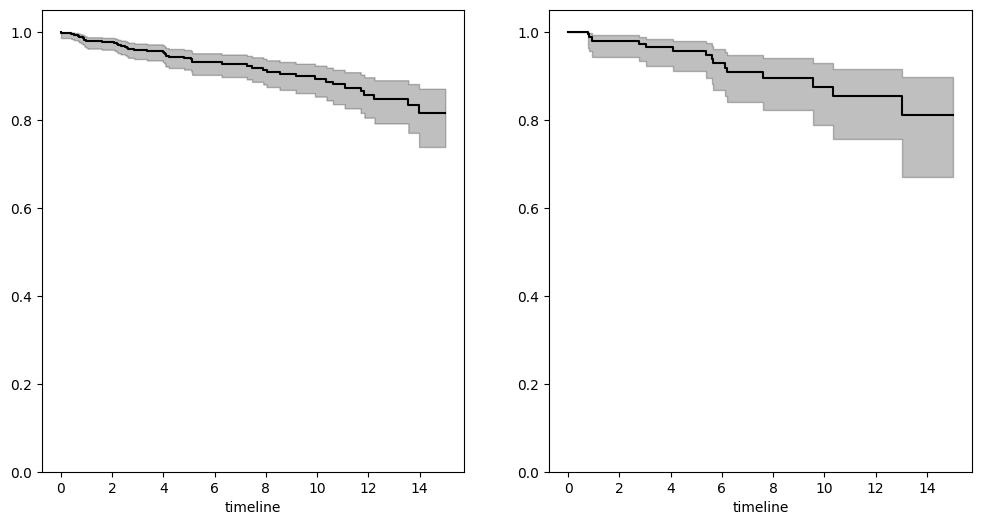

In [89]:
import oasis_utils

# Load exact dataset that was considered in the models applications
# Load OASIS data
# - Split into 75%/25% train/test sets
# - Stratify data according to the number of observed events
y_train, delta_train, x_train, y_test, delta_test, x_test =\
oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 15, stratify = True, verbose = True)
# oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 20, stratify = True, verbose = True)


fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)
plt.show()

In [3]:
def load_model(dist, model_type, base_dist, filename,
               y_train, delta_train, x_train, y_test, delta_test, x_test,
               fixed_q = 0.0, ngrid = 100):
    base_dist = base_dist.lower()
    if(base_dist == "exp" or base_dist == "exponential"):
        filename = "OASIS Results/ExponentialBase/{}".format(filename)
        base_spec = mpscr.BaseExponential()
    elif(base_dist == "weibull"):
        filename = "OASIS Results/WeibullBase/{}".format(filename)
        base_spec = mpscr.BaseWeibull()
    elif(base_dist == "pwexp"):
        filename = "OASIS Results/PwexpBase/{}".format(filename)
        base_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 5)
    else:
        raise Exception("Please, provide a valid base distribution.")

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    elif(dist == "borel"):
        # The Borel distribution is the Restricted Generalized Poisson with shape parameter q = 1
        model_spec = mpscr.MPSRGP(1.0)
    elif(dist == "geeta"):
        model_spec = mpscr.MPSGeeta()
    elif(dist == "haight" or dist == "catalan"):
        # The Haight distribution is the Geeta with shape parameter q = 2
        model_spec = mpscr.MPSGeeta(2.0)
    else:
        raise Exception("Please, provide a valid subfamily name.")

    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, base_spec, seed = 10 )
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = ngrid)
    elif(model_type == "medium"):
        with tf.device("/GPU:0"):
            medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = oasis_utils.build_neural_network_structure(1)
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = ngrid)
    
    
    return model, model_results

### Exponential models

In [4]:
exp_spec = mpscr.BaseExponential()

# Simple models
poisson_simple_model_exp, poisson_simple_results_exp = load_model("poisson", "simple", "exp", "poisson_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_exp, bin5_simple_results_exp = load_model("bin", "simple", "exp", "bin5_simple",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_simple_model_exp, negbin_simple_results_exp = load_model("negbin", "simple", "exp", "negbin_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_exp, log_simple_results_exp = load_model("log", "simple", "exp", "log_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_exp, rgp_simple_results_exp = load_model("rgp", "simple", "exp", "rgp_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_exp, borel_simple_results_exp = load_model("borel", "simple", "exp", "borel_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_exp, geeta_simple_results_exp = load_model("geeta", "simple", "exp", "geeta_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_exp, haight_simple_results_exp = load_model("haight", "simple", "exp", "haight_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)


# CNN medium models
poisson_medium_model_exp, poisson_medium_results_exp = load_model("poisson", "medium", "exp", "poisson_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_exp, bin5_medium_results_exp = load_model("bin", "medium", "exp", "bin5_medium",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_medium_model_exp, negbin_medium_results_exp = load_model("negbin", "medium", "exp", "negbin_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_exp, log_medium_results_exp = load_model("log", "medium", "exp", "log_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_exp, rgp_medium_results_exp = load_model("rgp", "medium", "exp", "rgp_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_exp, borel_medium_results_exp = load_model("borel", "medium", "exp", "borel_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_exp, geeta_medium_results_exp = load_model("geeta", "medium", "exp", "geeta_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_exp, haight_medium_results_exp = load_model("haight", "medium", "exp", "haight_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/ExponentialBase/poisson_simple.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_simple.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_simple.
Model successfully loaded from OASIS Results/ExponentialBase/log_simple.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_simple.
Model successfully loaded from OASIS Results/ExponentialBase/borel_simple.
Model successfully loaded from OASIS Results/ExponentialBase/geeta_simple.
Model successfully loaded from OASIS Results/ExponentialBase/haight_simple.
Model successfully loaded from OASIS Results/ExponentialBase/poisson_medium.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_medium.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_medium.
Model successfully loaded from OASIS Results/ExponentialBase/log_medium.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_medium.
Model successfully loaded fr

In [5]:
exp_results = [poisson_simple_results_exp, bin5_simple_results_exp, negbin_simple_results_exp, log_simple_results_exp,
               rgp_simple_results_exp, borel_simple_results_exp, geeta_simple_results_exp, haight_simple_results_exp,
               poisson_medium_results_exp, bin5_medium_results_exp, negbin_medium_results_exp, log_medium_results_exp,
               rgp_medium_results_exp, borel_medium_results_exp, geeta_medium_results_exp, haight_medium_results_exp]

### Weibull models

In [6]:
weibull_spec = mpscr.BaseWeibull()

# Simple models
poisson_simple_model_weibull, poisson_simple_results_weibull = load_model("poisson", "simple", "weibull", "poisson_simple",
                                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_weibull, bin5_simple_results_weibull = load_model("bin", "simple", "weibull", "bin5_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                    fixed_q = 5)
negbin_simple_model_weibull, negbin_simple_results_weibull = load_model("negbin", "simple", "weibull", "negbin_simple",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_weibull, log_simple_results_weibull = load_model("log", "simple", "weibull", "log_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_weibull, rgp_simple_results_weibull = load_model("rgp", "simple", "weibull", "rgp_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_weibull, borel_simple_results_weibull = load_model("borel", "simple", "weibull", "borel_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_weibull, geeta_simple_results_weibull = load_model("geeta", "simple", "weibull", "geeta_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_weibull, haight_simple_results_weibull = load_model("haight", "simple", "weibull", "haight_simple",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)

# CNN medium models
poisson_medium_model_weibull, poisson_medium_results_weibull = load_model("poisson", "medium", "weibull", "poisson_medium",
                                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_weibull, bin5_medium_results_weibull = load_model("bin", "medium", "weibull", "bin5_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                    fixed_q = 5)
negbin_medium_model_weibull, negbin_medium_results_weibull = load_model("negbin", "medium", "weibull", "negbin_medium",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_weibull, log_medium_results_weibull = load_model("log", "medium", "weibull", "log_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_weibull, rgp_medium_results_weibull = load_model("rgp", "medium", "weibull", "rgp_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_weibull, borel_medium_results_weibull = load_model("borel", "medium", "weibull", "borel_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_weibull, geeta_medium_results_weibull = load_model("geeta", "medium", "weibull", "geeta_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_weibull, haight_medium_results_weibull = load_model("haight", "medium", "weibull", "haight_medium",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/WeibullBase/poisson_simple.
Model successfully loaded from OASIS Results/WeibullBase/bin5_simple.
Model successfully loaded from OASIS Results/WeibullBase/negbin_simple.
Model successfully loaded from OASIS Results/WeibullBase/log_simple.
Model successfully loaded from OASIS Results/WeibullBase/rgp_simple.
Model successfully loaded from OASIS Results/WeibullBase/borel_simple.
Model successfully loaded from OASIS Results/WeibullBase/geeta_simple.
Model successfully loaded from OASIS Results/WeibullBase/haight_simple.
Model successfully loaded from OASIS Results/WeibullBase/poisson_medium.
Model successfully loaded from OASIS Results/WeibullBase/bin5_medium.
Model successfully loaded from OASIS Results/WeibullBase/negbin_medium.
Model successfully loaded from OASIS Results/WeibullBase/log_medium.
Model successfully loaded from OASIS Results/WeibullBase/rgp_medium.
Model successfully loaded from OASIS Results/WeibullBase/borel_medium.
Model suc

In [7]:
weibull_results = [poisson_simple_results_weibull, bin5_simple_results_weibull, negbin_simple_results_weibull, log_simple_results_weibull,
                   rgp_simple_results_weibull, borel_simple_results_weibull, geeta_simple_results_weibull, haight_simple_results_weibull,
                   poisson_medium_results_weibull, bin5_medium_results_weibull, negbin_medium_results_weibull, log_medium_results_weibull,
                   rgp_medium_results_weibull, borel_medium_results_weibull, geeta_medium_results_weibull, haight_medium_results_weibull]

### PiecewiseExp models

In [8]:
n_cuts = 5
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

# Simple models
poisson_simple_model_pwexp, poisson_simple_results_pwexp = load_model("poisson", "simple", "pwexp", "poisson_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_pwexp, bin5_simple_results_pwexp = load_model("bin", "simple", "pwexp", "bin5_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_simple_model_pwexp, negbin_simple_results_pwexp = load_model("negbin", "simple", "pwexp", "negbin_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_pwexp, log_simple_results_pwexp = load_model("log", "simple", "pwexp", "log_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_pwexp, rgp_simple_results_pwexp = load_model("rgp", "simple", "pwexp", "rgp_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_pwexp, borel_simple_results_pwexp = load_model("borel", "simple", "pwexp", "borel_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_pwexp, geeta_simple_results_pwexp = load_model("geeta", "simple", "pwexp", "geeta_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_pwexp, haight_simple_results_pwexp = load_model("haight", "simple", "pwexp", "haight_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)

# CNN medium models
poisson_medium_model_pwexp, poisson_medium_results_pwexp = load_model("poisson", "medium", "pwexp", "poisson_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_pwexp, bin5_medium_results_pwexp = load_model("bin", "medium", "pwexp", "bin5_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_medium_model_pwexp, negbin_medium_results_pwexp = load_model("negbin", "medium", "pwexp", "negbin_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_pwexp, log_medium_results_pwexp = load_model("log", "medium", "pwexp", "log_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_pwexp, rgp_medium_results_pwexp = load_model("rgp", "medium", "pwexp", "rgp_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_pwexp, borel_medium_results_pwexp = load_model("borel", "medium", "pwexp", "borel_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_pwexp, geeta_medium_results_pwexp = load_model("geeta", "medium", "pwexp", "geeta_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_pwexp, haight_medium_results_pwexp = load_model("haight", "medium", "pwexp", "haight_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/PwexpBase/poisson_simple.
Model successfully loaded from OASIS Results/PwexpBase/bin5_simple.
Model successfully loaded from OASIS Results/PwexpBase/negbin_simple.
Model successfully loaded from OASIS Results/PwexpBase/log_simple.
Model successfully loaded from OASIS Results/PwexpBase/rgp_simple.
Model successfully loaded from OASIS Results/PwexpBase/borel_simple.
Model successfully loaded from OASIS Results/PwexpBase/geeta_simple.
Model successfully loaded from OASIS Results/PwexpBase/haight_simple.
Model successfully loaded from OASIS Results/PwexpBase/poisson_medium.
Model successfully loaded from OASIS Results/PwexpBase/bin5_medium.
Model successfully loaded from OASIS Results/PwexpBase/negbin_medium.
Model successfully loaded from OASIS Results/PwexpBase/log_medium.
Model successfully loaded from OASIS Results/PwexpBase/rgp_medium.
Model successfully loaded from OASIS Results/PwexpBase/borel_medium.
Model successfully loaded from OASIS 

In [9]:
pwexp_results = [poisson_simple_results_pwexp, bin5_simple_results_pwexp, negbin_simple_results_pwexp, log_simple_results_pwexp,
                 rgp_simple_results_pwexp, borel_simple_results_pwexp, geeta_simple_results_pwexp, haight_simple_results_pwexp,
                 poisson_medium_results_pwexp, bin5_medium_results_pwexp, negbin_medium_results_pwexp, log_medium_results_pwexp,
                 rgp_medium_results_pwexp, borel_medium_results_pwexp, geeta_medium_results_pwexp, haight_medium_results_pwexp]

## Evaluation metrics

In [10]:
all_results = exp_results + weibull_results + pwexp_results

In [ ]:
poisson_simple.
bin5_simple
negbin_simple
log_simple
rgp_simple
borel_simple
geeta_simple
haight_simple

In [144]:
from scipy.stats import anderson
import evaluation_metrics as eval_metrics

# For each model, obtain the desirable evaluation metrics
ad_statistics = []
ibs_statistics = []
bs_curves_times = []
mean_uno_statistics = []
auc_curves_times = []

for i, model_results in enumerate(all_results):
    resid_model_test = utils.compute_randomized_residuals_censoring( model_results["S_test"], model_results["delta_test"] )
    model_ad = anderson(resid_model_test).statistic

    # Curve evaluation values
    grid_times_bs, bs_times = eval_metrics.calculate_ipcw_brier_score(model_results)
    
    # Point evaluation values
    model_ibs = eval_metrics.calculate_integrated_ipcw_brier_score(model_results)
    grid_times_auc, uno_auc_times, mean_uno_auc = eval_metrics.calculate_unos_auc( model_results )

    # Append the curves evaluation metrics (time dependent BS and AUC)
    bs_curves_times.append( bs_times )
    auc_curves_times.append( uno_auc_times )

    # Append the point evaluation metrics (integrated BS and averaged AUC)
    ad_statistics.append(model_ad)
    ibs_statistics.append(model_ibs)
    
    mean_uno_statistics.append(mean_uno_auc)

model_base_dist = ["Exp"] * 16 + ["Weibull"] * 16 + ["Pwexp"] * 16
model_mps_dist = np.tile( ["Poisson", "Bin(5)", "NegBin", "Log", "RGP", "Borel", "Geeta", "Haight"] * 2, 3 )
model_types = np.tile( ["Simple"] * 8 + ["CNN"] * 8, 3 )

model_results = pd.DataFrame({
    "Base dist": model_base_dist,
    "Model type": model_types,
    "MPS dist": model_mps_dist, 
    "AD": ad_statistics,
    "IBS": ibs_statistics,
    "Mean AUC": mean_uno_statistics
})

print("Top 10 best models according to the AD metric")
top_10_AD = model_results.sort_values(by = "AD").head(10)
display( top_10_AD )
print("Top 10 best models according to the IBS metric")
top_10_IBS = model_results.sort_values(by = "IBS").head(10)
display( top_10_IBS )
print("Top 10 best models according to the mean AUC metric")
top_10_AUC = model_results.sort_values(by = "Mean AUC", ascending = False).head(10)
display( top_10_AUC )

Top 10 best models according to the AD metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
40,Pwexp,CNN,Poisson,0.171600,0.075961,0.713073
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
42,Pwexp,CNN,NegBin,0.176325,0.076298,0.712220
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593
45,Pwexp,CNN,Borel,0.186891,0.077101,0.711413
47,Pwexp,CNN,Haight,0.193088,0.078649,0.706291
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
46,Pwexp,CNN,Geeta,0.194743,0.077269,0.707897
14,Exp,CNN,Geeta,0.202934,0.086079,0.663532


Top 10 best models according to the IBS metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
40,Pwexp,CNN,Poisson,0.171600,0.075961,0.713073
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
42,Pwexp,CNN,NegBin,0.176325,0.076298,0.712220
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
45,Pwexp,CNN,Borel,0.186891,0.077101,0.711413
46,Pwexp,CNN,Geeta,0.194743,0.077269,0.707897
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766


Top 10 best models according to the mean AUC metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
27,Weibull,CNN,Log,0.277453,0.079195,0.727918
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766
24,Weibull,CNN,Poisson,0.268120,0.078498,0.724927
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
10,Exp,CNN,NegBin,0.248656,0.078651,0.718037
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593


In [141]:
model_results.sort_values("Mean AUC", ascending = False)
# model_results.sort_values("IBS")

,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
27,Weibull,CNN,Log,0.277453,0.079195,0.727918
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766
24,Weibull,CNN,Poisson,0.268120,0.078498,0.724927
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
10,Exp,CNN,NegBin,0.248656,0.078651,0.718037
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593


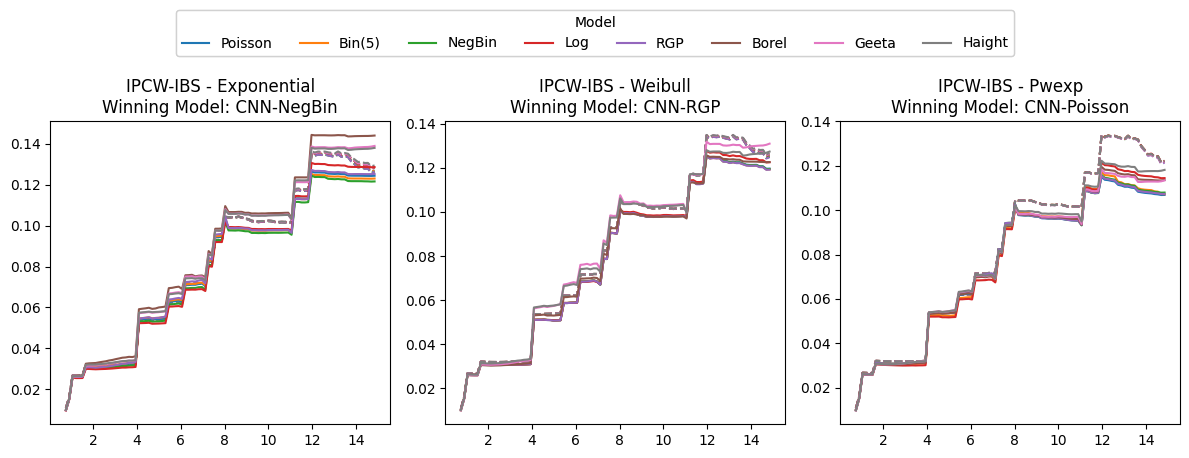

In [134]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
group_handles = []

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

for i in range(model_results.shape[0]):
    if(model_results.iloc[i,1] == "Simple"):
        linestyle = "dashed"
    else:
        linestyle = "solid"

    if(model_results.iloc[i,0] == "Exp"):
        # mask = grid_times_bs > 12
        # ax[0].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[0].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Weibull"):
        # mask = grid_times_bs > 12
        # ax[0].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[1].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Pwexp"):
        # mask = grid_times_bs > 12
        # ax[2].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[2].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])

group_handles = [
    Line2D([0], [0], color = colors[0], linestyle = '-', label = "Poisson"),
    Line2D([0], [0], color = colors[1], linestyle = '-', label = "Bin(5)"),
    Line2D([0], [0], color = colors[2], linestyle = '-', label = "NegBin"),
    Line2D([0], [0], color = colors[3], linestyle = '-', label = "Log"),
    Line2D([0], [0], color = colors[4], linestyle = '-', label = "RGP"),
    Line2D([0], [0], color = colors[5], linestyle = '-', label = "Borel"),
    Line2D([0], [0], color = colors[6], linestyle = '-', label = "Geeta"),
    Line2D([0], [0], color = colors[7], linestyle = '-', label = "Haight"),
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.15), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = 8
)

exp_results = model_results.loc[model_results["Base dist"] == "Exp", :].sort_values("IBS")
ax[0].set_title("IPCW-IBS - Exponential\nWinning Model: {}-{}".format( exp_results.iloc[0,1], exp_results.iloc[0,2] ))

weibull_results = model_results.loc[model_results["Base dist"] == "Weibull", :].sort_values("IBS")
ax[1].set_title("IPCW-IBS - Weibull\nWinning Model: {}-{}".format( weibull_results.iloc[0,1], weibull_results.iloc[0,2] ))

pwexp_results = model_results.loc[model_results["Base dist"] == "Pwexp", :].sort_values("IBS")
ax[2].set_title("IPCW-IBS - Pwexp\nWinning Model: {}-{}".format( pwexp_results.iloc[0,1], pwexp_results.iloc[0,2] ))

fig.add_artist(legend1)
fig.tight_layout()

# group_handles.append( Line2D([0], [0], color = colors[i % 8], linestyle = '-', label = model_names[i]) )

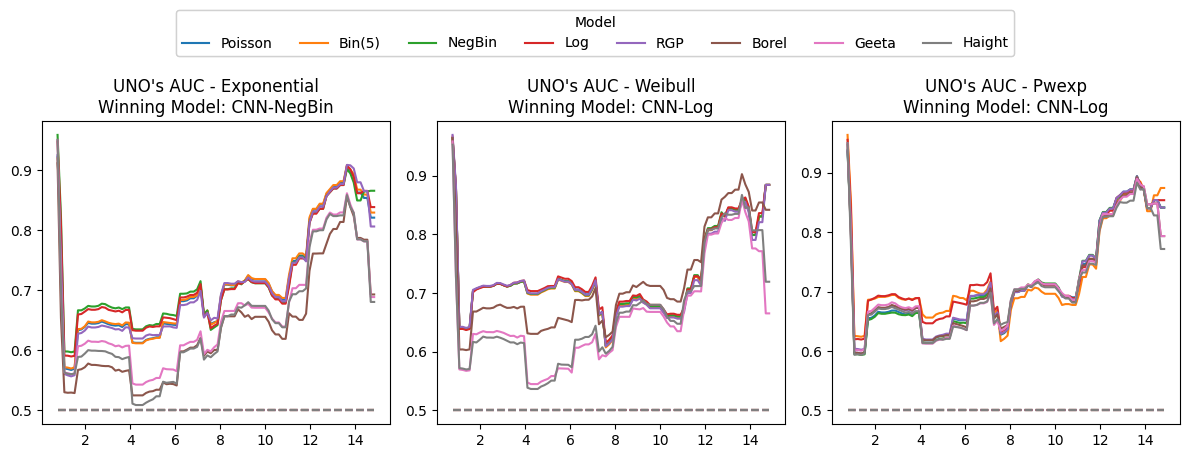

In [140]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
group_handles = []

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

for i in range(model_results.shape[0]):
    if(model_results.iloc[i,1] == "Simple"):
        linestyle = "dashed"
    else:
        linestyle = "solid"

    if(model_results.iloc[i,0] == "Exp"):
        # mask = grid_times_auc > 12
        # ax[0].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[0].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Weibull"):
        # mask = grid_times_auc > 12
        # ax[0].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[1].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Pwexp"):
        # mask = grid_times_auc > 12
        # ax[2].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[2].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])

group_handles = [
    Line2D([0], [0], color = colors[0], linestyle = '-', label = "Poisson"),
    Line2D([0], [0], color = colors[1], linestyle = '-', label = "Bin(5)"),
    Line2D([0], [0], color = colors[2], linestyle = '-', label = "NegBin"),
    Line2D([0], [0], color = colors[3], linestyle = '-', label = "Log"),
    Line2D([0], [0], color = colors[4], linestyle = '-', label = "RGP"),
    Line2D([0], [0], color = colors[5], linestyle = '-', label = "Borel"),
    Line2D([0], [0], color = colors[6], linestyle = '-', label = "Geeta"),
    Line2D([0], [0], color = colors[7], linestyle = '-', label = "Haight"),
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.15), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = 8
)

exp_results = model_results.loc[model_results["Base dist"] == "Exp", :].sort_values("Mean AUC", ascending = False)
ax[0].set_title("UNO's AUC - Exponential\nWinning Model: {}-{}".format( exp_results.iloc[0,1], exp_results.iloc[0,2] ))

weibull_results = model_results.loc[model_results["Base dist"] == "Weibull", :].sort_values("Mean AUC", ascending = False)
ax[1].set_title("UNO's AUC - Weibull\nWinning Model: {}-{}".format( weibull_results.iloc[0,1], weibull_results.iloc[0,2] ))

pwexp_results = model_results.loc[model_results["Base dist"] == "Pwexp", :].sort_values("Mean AUC", ascending = False)
ax[2].set_title("UNO's AUC - Pwexp\nWinning Model: {}-{}".format( pwexp_results.iloc[0,1], pwexp_results.iloc[0,2] ))

fig.add_artist(legend1)
fig.tight_layout()

# group_handles.append( Line2D([0], [0], color = colors[i % 8], linestyle = '-', label = model_names[i]) )

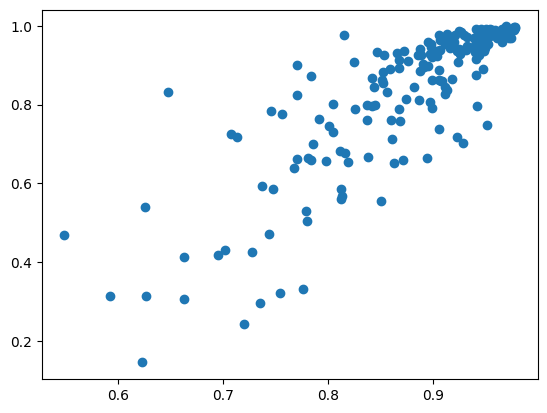

In [176]:
# Comparison between the cure probability predictions for the Negative Binomial Weibull and Pwexp models
negbin_spec = mpscr.MPSNegBinomial()
q_negbin_weibull = negbin_medium_model_weibull.predict("q")
raw_p_negbin_weibull = negbin_medium_model_weibull.predict(x_test)["raw_p"].numpy().flatten()
p_negbin_weibull = tf.math.sigmoid(raw_p_negbin_weibull).numpy()

q_rgp_pwexp = negbin_medium_model_pwexp.predict("q")
raw_p_negbin_pwexp = negbin_medium_model_pwexp.predict(x_test)["raw_p"].numpy().flatten()
p_negbin_pwexp = tf.math.sigmoid(raw_p_negbin_pwexp).numpy()

plt.plot(p_negbin_weibull, p_negbin_pwexp, "o")
plt.show()

## Final Model Analysis

Judging by the three top 10 results matrices, we select the winning model as the one that considers the piecewise-exponential distribution with 5 knots as the base while also considering the standard Poisson distribution for the number of latent causes. Surprisingly, that is the exact same model originally proposed by Xie & Yu (2021), event though here we consider a bigger dataset while also adopting a completely different approach to the model, where we optimize the observed log-likelihood function directly, without resorting to the EM algorithm.

That result suggests that our generalization works quite well and that the original structure proposed by Xie & Yu is mantained. With these results, we are much more confident of the predicting results for each patient. Here we can also rely on the GNDR models framework to obtain confidence intervals for the survival predictions, which provided a much more robust and stable calculation than obtaining predictive intervals using the Bootstrap method.

In fact, below, we fix the Piecewise-exponential Poisson promotion time cure model as the selected model and all following conclusions are obtained considering that specific approach.